In [5]:
# ============================================================
# SECTION 0 — ENVIRONMENT + LOCAL PATH SETUP
# ============================================================

import os, re, io, glob, json, math, zipfile, dataclasses, warnings
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Tuple, Dict

import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ============================================================
# LOCAL JUPYTER SETUP
# ============================================================

# We are running locally in Jupyter, not Google Colab.
COLAB = False

# ---- LOCAL PATHS ----
# Main project directory
PROJECT_ROOT = r"D:\ISRO"

# Root folder containing all downloaded IIRS scenes
DATA_ROOT = os.path.join(PROJECT_ROOT, "IIRS_raws")

# Output folder for reduced IIRS tiles + manifest
OUT_ROOT = os.path.join(PROJECT_ROOT, "IIRS_tiles")

os.makedirs(OUT_ROOT, exist_ok=True)

print("Project root     :", PROJECT_ROOT)
print("Data root        :", DATA_ROOT)
print("Data root exists :", os.path.exists(DATA_ROOT))
print("Output folder    :", OUT_ROOT)
print("Output exists    :", os.path.exists(OUT_ROOT))

# ------------------------------------------------------------
# Current sample scene
# ------------------------------------------------------------
SAMPLE_ROOT = os.path.join(
    DATA_ROOT,
    "ch2_iir_nci_20260227T1239538758_d_img_d18"
)

print("Sample scene     :", SAMPLE_ROOT)
print("Sample exists    :", os.path.exists(SAMPLE_ROOT))

# ------------------------------------------------------------
# PDS4 namespaces
# ------------------------------------------------------------
PDS_NS = {
    "pds": "http://pds.nasa.gov/pds4/pds/v1",
    "isda": "https://isda.issdc.gov.in/pds4/isda/v1"
}

Project root     : D:\ISRO
Data root        : D:\ISRO\IIRS_raws
Data root exists : True
Output folder    : D:\ISRO\IIRS_tiles
Output exists    : True
Sample scene     : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18
Sample exists    : True


In [6]:
COMMON_PATCH_SIZE = 256          # pixels, per Day-1 contract (edit to match team agreement)
IIRS_CHANNELS = 2               # structural + illumination-invariant
@dataclass
class PatchMetadata:
    """One row of the shared metadata schema (Section 1 of the build guide)."""
    source_scene_id: str
    sensor_id: str = "IIRS"
    tile_row: int = 0
    tile_col: int = 0
    lat: float = float("nan")
    lon: float = float("nan")
    resolution_m_per_px: float = float("nan")
    sun_azimuth: float = float("nan")
    sun_elevation: float = float("nan")
    solar_incidence: float = float("nan")
    spacecraft_altitude_km: float = float("nan")
    orbit_number: Optional[int] = None
    # QA / edge-case flags (see Section 8)
    valid_fraction: float = 1.0
    flag_low_signal: bool = False       # e.g. permanently shadowed polar terrain
    flag_geoloc_missing: bool = False   # geometry grid didn't cover this tile
    flag_corrupt: bool = False
    tile_path: str = ""

In [7]:
SAMPLE = dict(
    img_xml = os.path.join(
        SAMPLE_ROOT,
        "data", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_d_img_d18.xml"
    ),
    img_hdr = os.path.join(
        SAMPLE_ROOT,
        "data", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_d_img_d18.hdr"
    ),
    img_qub = os.path.join(
        SAMPLE_ROOT,
        "data", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_d_img_d18.qub"
    ),  # too large to have shipped in chat
    grd_csv = os.path.join(
        SAMPLE_ROOT,
        "geometry", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_g_grd_d18.csv"
    ),
    grd_xml = os.path.join(
        SAMPLE_ROOT,
        "geometry", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_g_grd_d18.xml"
    ),
    brw_png = os.path.join(
        SAMPLE_ROOT,
        "browse", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_b_brw_d18.png"
    ),
    oath = os.path.join(
        SAMPLE_ROOT,
        "miscellaneous", "calibrated", "20260227",
        "ch2_iir_nci_20260227T1239538758_d_img_d18.oath"
    ),
)

# ------------------------------------------------------------
# Verify that all expected sample files exist
# ------------------------------------------------------------

print("=== SAMPLE FILES ===")
for key, path in SAMPLE.items():
    print(f"{key:8s}: {path}")
    print(f"{'':10s}exists -> {os.path.exists(path)}")

# Required files for the preprocessing pipeline
assert os.path.exists(SAMPLE["img_xml"]), "Missing IIRS image XML"
assert os.path.exists(SAMPLE["img_hdr"]), "Missing IIRS ENVI HDR"
assert os.path.exists(SAMPLE["img_qub"]), "Missing IIRS QUB cube"
assert os.path.exists(SAMPLE["grd_csv"]), "Missing IIRS geometry CSV"

print("\nAll required sample files found.")

def parse_envi_hdr(hdr_path: str) -> dict:
    """Tiny ENVI header parser -- used both to sanity-check GDAL's own read and
    as the fallback path if GDAL/rasterio can't open a given .qub directly."""
    out = {}
    with open(hdr_path, "r", errors="ignore") as f:
        for line in f:
            if "=" in line:
                k, v = line.split("=", 1)
                out[k.strip().lower()] = v.strip()
    return {
        "samples": int(out["samples"]),
        "lines": int(out["lines"]),
        "bands": int(out["bands"]),
        "header_offset": int(out.get("header offset", 0)),
        "interleave": out.get("interleave", "bsq").lower(),
        "data_type_envi": int(out.get("data type", 4)),
        "byte_order": int(out.get("byte order", 0)),  # 0 = little-endian
    }

ENVI_DTYPE_MAP = {
    1: np.uint8,
    2: np.int16,
    3: np.int32,
    4: np.float32,
    5: np.float64,
    12: np.uint16,
    13: np.uint32
}

def parse_iirs_pds4_label(xml_path: str) -> dict:
    """Parse the fields we actually need out of the PDS4 label."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    def find(path):
        el = root.find(path, PDS_NS)
        return el.text.strip() if el is not None and el.text else None

    params = root.find(".//isda:Product_Parameters", PDS_NS)

    def pparam(tag, cast=float):
        el = params.find(f"isda:{tag}", PDS_NS) if params is not None else None
        return cast(el.text) if el is not None and el.text else None

    # Band_Bin_Set -> wavelength table
    # (this is what lets us find the real 800-1000nm indices)
    bands = []

    for bb in root.findall(".//pds:Band_Bin", PDS_NS):
        bn = bb.find("pds:band_number", PDS_NS)
        cw = bb.find("pds:center_wavelength", PDS_NS)
        bw = bb.find("pds:band_width", PDS_NS)

        if bn is not None and cw is not None:
            bands.append(
                (
                    int(bn.text),
                    float(cw.text),
                    float(bw.text) if bw is not None else None
                )
            )

    bands.sort(key=lambda t: t[0])

    axes = {}

    for ax in root.findall(".//pds:Axis_Array", PDS_NS):
        name = ax.find("pds:axis_name", PDS_NS).text
        elems = int(ax.find("pds:elements", PDS_NS).text)
        axes[name] = elems

    unit_el = root.find(".//pds:Element_Array/pds:unit", PDS_NS)

    refined = root.find(
        ".//isda:Refined_Corner_Coordinates",
        PDS_NS
    )

    corners = {}

    if refined is not None:
        for corner in (
            "upper_left",
            "upper_right",
            "lower_left",
            "lower_right"
        ):
            lat = refined.find(
                f"isda:{corner}_latitude",
                PDS_NS
            )

            lon = refined.find(
                f"isda:{corner}_longitude",
                PDS_NS
            )

            corners[corner] = (
                float(lat.text),
                float(lon.text)
            )

    file_name_el = root.find(
        ".//pds:File/pds:file_name",
        PDS_NS
    )

    return {
        "logical_identifier": find(
            ".//pds:logical_identifier"
        ),

        "start_time": find(
            ".//pds:Time_Coordinates/pds:start_date_time"
        ),

        "stop_time": find(
            ".//pds:Time_Coordinates/pds:stop_date_time"
        ),

        "processing_level": find(
            ".//pds:Primary_Result_Summary/pds:processing_level"
        ),

        "radiometric_unit":
            unit_el.text if unit_el is not None else None,

        "sun_azimuth":
            pparam("sun_azimuth"),

        "sun_elevation":
            pparam("sun_elevation"),

        "solar_incidence":
            pparam("solar_incidence"),

        "pixel_resolution_m":
            pparam("pixel_resolution"),

        "spacecraft_altitude_km":
            pparam("spacecraft_altitude"),

        "imaging_orbit_number":
            pparam("imaging_orbit_number", int),

        "orbit_limb_direction":
            pparam("orbit_limb_direction", str),

        "bands": bands,

        "n_bands":
            axes.get("BAND"),

        "n_lines":
            axes.get("LINE"),

        "n_samples":
            axes.get("SAMPLE"),

        "corners":
            corners,

        "cube_file_name":
            file_name_el.text
            if file_name_el is not None
            else None,
    }


meta = parse_iirs_pds4_label(SAMPLE["img_xml"])
hdr = parse_envi_hdr(SAMPLE["img_hdr"])

print("=== PDS4 label summary ===")

for k, v in meta.items():
    if k != "bands":
        print(f"  {k}: {v}")

print(
    f"  bands: {len(meta['bands'])} entries, "
    f"{meta['bands'][0][1]}nm -> {meta['bands'][-1][1]}nm"
)

print()

print("=== ENVI sidecar .hdr (should match the label) ===")
print(" ", hdr)

assert hdr["bands"] == meta["n_bands"] == len(meta["bands"])
assert hdr["lines"] == meta["n_lines"]
assert hdr["samples"] == meta["n_samples"]

print(
    "\nShape check OK -> cube is "
    "(bands=%d, lines=%d, samples=%d), dtype=%s, interleave=%s"
    % (
        hdr["bands"],
        hdr["lines"],
        hdr["samples"],
        ENVI_DTYPE_MAP[hdr["data_type_envi"]],
        hdr["interleave"]
    )
)

if meta["radiometric_unit"] and "sr" in meta["radiometric_unit"]:
    print(
        f"\nNOTE: radiometric unit is "
        f"'{meta['radiometric_unit']}' -> this is CALIBRATED "
        f"RADIANCE, not reflectance (filename suffix is '_d_img', "
        f"not '_rfl'). Downstream normalization must not assume "
        f"a reflectance product."
    )

=== SAMPLE FILES ===
img_xml : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\data\calibrated\20260227\ch2_iir_nci_20260227T1239538758_d_img_d18.xml
          exists -> True
img_hdr : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\data\calibrated\20260227\ch2_iir_nci_20260227T1239538758_d_img_d18.hdr
          exists -> True
img_qub : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\data\calibrated\20260227\ch2_iir_nci_20260227T1239538758_d_img_d18.qub
          exists -> True
grd_csv : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\geometry\calibrated\20260227\ch2_iir_nci_20260227T1239538758_g_grd_d18.csv
          exists -> True
grd_xml : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\geometry\calibrated\20260227\ch2_iir_nci_20260227T1239538758_g_grd_d18.xml
          exists -> True
brw_png : D:\ISRO\IIRS_raws\ch2_iir_nci_20260227T1239538758_d_img_d18\browse\calibrated\20260227\ch2_iir_nci_20260227T1239538758_b_brw_d18.pn

In [8]:
# Peek at the sparse geolocation control-point grid.

grd = pd.read_csv(SAMPLE["grd_csv"])
print(grd.head())
print(
    f"\n{len(grd)} control points, "
    f"Pixel in [{grd.Pixel.min()},{grd.Pixel.max()}], "
    f"Scan in [{grd.Scan.min()},{grd.Scan.max()}]"
)
print(
    f"Unique pixel columns sampled: "
    f"{sorted(grd.Pixel.unique())}"
)
print(
    f"Scan rows sampled every ~"
    f"{np.diff(sorted(grd.Scan.unique())).max()} lines "
    f"(irregular at the last row/col -> use scattered interpolation, "
    f"not a regular grid reshape)"
)

    Longitude  Latitude  Pixel  Scan
0  356.499296 -6.511964      0     0
1  356.382427 -6.515915     50     0
2  356.265610 -6.519817    100     0
3  356.148815 -6.523672    150     0
4  356.032015 -6.527480    200     0

1476 control points, Pixel in [0,249], Scan in [0,12209]
Unique pixel columns sampled: [np.int64(0), np.int64(50), np.int64(100), np.int64(150), np.int64(200), np.int64(249)]
Scan rows sampled every ~50 lines (irregular at the last row/col -> use scattered interpolation, not a regular grid reshape)


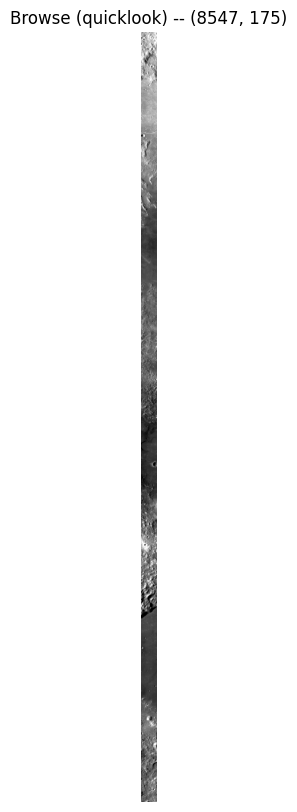

{'record_type': 'ORBTATTD-HDR', 'project': 'CHANDRAYAAN-2 MISSION', 'header_len': 201, 'station': 'BLR', 'start_utc_raw': '2026   2  27  12  39  53 482', 'end_utc_raw': '2026   2  27  12  50  45 642', 'n_oat_records': 16305, 'oat_record_len': 601, 'attitude_source': '2', 'mission_phase': '3'}


In [9]:
# Browse image + orbit/attitude header sanity check.
# NOTE (found during inspection): this sample's *.png browse file actually
# decodes as JPEG-compressed data despite the .png extension (PIL/libjpeg
# reads it fine; a strict PNG-only decoder -- e.g. matplotlib's imread
# dispatching purely on extension -- does not).
# Don't trust the extension for any of your 624 downloads:
# sniff content, don't assume.

from PIL import Image
img = np.array(
    Image.open(SAMPLE["brw_png"]).convert("L")
)

plt.figure(figsize=(2.5, 10))
plt.imshow(img, cmap="gray")
plt.title(f"Browse (quicklook) -- {img.shape}")
plt.axis("off")
plt.show()

def parse_oath(oath_path: str) -> dict:
    """Fixed-width ASCII header for the .oat orbit/attitude file
    (see readme.txt table 1)."""

    with open(oath_path, "r") as f:
        s = f.read()

    return {
        "record_type": s[0:12].strip(),
        "project": s[12:33].strip(),
        "header_len": int(s[33:39]),
        "station": s[39:43].strip(),
        "start_utc_raw": s[43:71],
        "end_utc_raw": s[71:99],
        "n_oat_records": int(s[99:105]),
        "oat_record_len": int(s[105:111]),
        "attitude_source": s[111:112],   # 1=SS1, 2=SS2, 3=ECI QS
        "mission_phase": s[112:113],     # 1=Earth-centered, 3=Moon-centered
    }

print(parse_oath(SAMPLE["oath"]))

In [10]:
def open_iirs_cube(qub_path: str, hdr_path: Optional[str] = None):
    """
    Returns a numpy memmap-like array shaped (bands, lines, samples), float32.

    The IIRS .qub file is very large (~3.1 GB), so we avoid loading the
    complete cube into RAM.

    The .hdr file provides the dimensions, data type, byte order, and
    interleave. For the current IIRS product this is:
        bands   = 256
        lines   = 12210
        samples = 250
        dtype   = float32
        order   = BSQ

    A manual numpy memmap is therefore used as the primary path. This allows
    later processing to access the data from disk without materializing the
    entire 3.1 GB cube in memory.
    """

    if hdr_path is None:
        hdr_path = os.path.splitext(qub_path)[0] + ".hdr"

    # ------------------------------------------------------------
    # Read ENVI header
    # ------------------------------------------------------------
    h = parse_envi_hdr(hdr_path)
    dtype = ENVI_DTYPE_MAP[h["data_type_envi"]]
    order = "<" if h["byte_order"] == 0 else ">"
    dt = np.dtype(order + np.dtype(dtype).char)

    # ------------------------------------------------------------
    # Calculate expected number of elements
    # ------------------------------------------------------------
    count = (
        h["bands"]
        * h["lines"]
        * h["samples"]
    )

    # ------------------------------------------------------------
    # Memory-map the .qub file
    # ------------------------------------------------------------
    arr = np.memmap(
        qub_path,
        dtype=dt,
        mode="r",
        offset=h["header_offset"],
        shape=(count,)
    )

    # ------------------------------------------------------------
    # Convert ENVI interleave into:
    # (bands, lines, samples)
    # ------------------------------------------------------------
    if h["interleave"] == "bsq":

        cube = arr.reshape(
            h["bands"],
            h["lines"],
            h["samples"]
        )

    elif h["interleave"] == "bil":

        cube = arr.reshape(
            h["lines"],
            h["bands"],
            h["samples"]
        ).transpose(1, 0, 2)

    elif h["interleave"] == "bip":

        cube = arr.reshape(
            h["lines"],
            h["samples"],
            h["bands"]
        ).transpose(2, 0, 1)

    else:
        raise ValueError(
            f"Unknown interleave: {h['interleave']}"
        )

    # ------------------------------------------------------------
    # Sanity checks against the .hdr
    # ------------------------------------------------------------
    assert cube.shape == (
        h["bands"],
        h["lines"],
        h["samples"]
    ), (
        f"Unexpected cube shape: {cube.shape}; "
        f"expected {(h['bands'], h['lines'], h['samples'])}"
    )

    print(
        f"[open_iirs_cube] Memory-mapped cube: "
        f"shape={cube.shape}, dtype={cube.dtype}, "
        f"interleave={h['interleave']}"
    )

    return cube


# ------------------------------------------------------------
# Uncomment once you want to test the .qub.
#
# IMPORTANT:
# This does NOT load the complete 3.1 GB cube into RAM.
# ------------------------------------------------------------

# cube = open_iirs_cube(
#     SAMPLE["img_qub"],
#     SAMPLE["img_hdr"]
# )

# print(cube.shape, cube.dtype)
# -> (256, 12210, 250) float32

In [11]:
def vnir_band_indices(
    bands: List[Tuple[int, float, float]],
    lo_nm=800.0,
    hi_nm=1000.0
) -> np.ndarray:
    """
    bands: list of
    (band_number, center_wavelength_nm, band_width_nm),
    1-indexed band_number.

    Returns 0-indexed positions into the cube's band axis.
    """

    wl = np.array([b[1] for b in bands])

    idx = np.where(
        (wl >= lo_nm) &
        (wl <= hi_nm)
    )[0]

    if len(idx) == 0:
        # Fall back to nearest single band if the range is empty
        # for some scene's calibration table.
        idx = np.array([
            int(
                np.argmin(
                    np.abs(
                        wl - (lo_nm + hi_nm) / 2
                    )
                )
            )
        ])

    return idx


def band_reduce_mean(
    cube: np.ndarray,
    band_idx: np.ndarray
) -> np.ndarray:
    """
    cube: (bands, lines, samples)
    -> (lines, samples) structural composite.

    The cube may be a numpy memmap backed by the ~3.1 GB .qub
    file. Selected bands are accumulated one at a time so that
    cube[band_idx] does not create a large temporary array in RAM.
    """

    band_idx = np.asarray(band_idx, dtype=int)

    if len(band_idx) == 0:
        raise ValueError("band_idx is empty.")

    L = cube.shape[1]
    S = cube.shape[2]

    # Accumulator for the mean structural image.
    total = np.zeros(
        (L, S),
        dtype=np.float64
    )

    valid_count = np.zeros(
        (L, S),
        dtype=np.uint16
    )

    for i in band_idx:

        band = np.asarray(
            cube[i],
            dtype=np.float32
        )

        valid = np.isfinite(band)

        total[valid] += band[valid]
        valid_count[valid] += 1

        del band

    structural = np.full(
        (L, S),
        np.nan,
        dtype=np.float32
    )

    valid = valid_count > 0

    structural[valid] = (
        total[valid] /
        valid_count[valid]
    ).astype(np.float32)

    return structural


def band_reduce_pca(
    cube: np.ndarray,
    band_idx: np.ndarray,
    n_components: int = 1
) -> np.ndarray:
    """
    Alternative: PCA over the selected bands, first component only.

    Useful for your report ('we tried both'); not used as the default
    matching channel because PCA sign/scale isn't guaranteed consistent
    scene-to-scene.
    """

    sub = cube[band_idx]  # (k, lines, samples)

    k, L, S = sub.shape

    flat = sub.reshape(
        k,
        L * S
    ).T  # (L*S, k)

    valid = np.isfinite(flat).all(axis=1)

    out = np.zeros(
        L * S,
        dtype=np.float32
    )

    if valid.sum() > n_components:

        from sklearn.decomposition import PCA

        pca = PCA(
            n_components=n_components
        )

        comp = pca.fit_transform(
            flat[valid]
        )

        out[valid] = comp[:, 0]

    return out.reshape(L, S)


def radiance_to_unit_range(
    structural: np.ndarray,
    lo_pct=1.0,
    hi_pct=99.0
) -> np.ndarray:
    """
    This is CALIBRATED RADIANCE (uW/cm^2/sr/um),
    not reflectance -> we cannot divide by a solar spectrum
    lookup here without extra per-band solar-irradiance constants.

    For the matching pipeline (not the mineralogy pipeline), a
    robust percentile stretch to [0,1] is the correct, defensible
    normalization.

    Record lo/hi in the manifest so it's reproducible.
    """

    finite = structural[
        np.isfinite(structural)
    ]

    lo, hi = (
        np.percentile(
            finite,
            [lo_pct, hi_pct]
        )
        if finite.size
        else (0.0, 1.0)
    )

    out = np.clip(
        (structural - lo) /
        max(hi - lo, 1e-6),
        0.0,
        1.0
    )

    return (
        out.astype(np.float32),
        float(lo),
        float(hi)
    )


# ------------------------------------------------------------
# Example (once `cube` and `meta` exist):
# ------------------------------------------------------------

# vidx = vnir_band_indices(meta["bands"])

# print(
#     "VNIR band indices used:",
#     vidx,
#     "-> wavelengths:",
#     [meta["bands"][i][1] for i in vidx]
# )

# structural_raw = band_reduce_mean(cube, vidx)

# structural, lo, hi = radiance_to_unit_range(structural_raw)

In [12]:
from scipy.ndimage import gaussian_filter


def illumination_invariant_weber(
    structural: np.ndarray,
    sigma_px: float = 15.0,
    eps: float = 1e-3
) -> np.ndarray:
    """
    Local-contrast-normalized ('Weber ratio') image.

    sigma_px should scale with the footprint you expect a lunar feature
    (crater rim, boulder field) to occupy in pixels -- 15px is a reasonable
    default for a 256x256 patch at IIRS's ~73 m/px.
    """

    # ------------------------------------------------------------
    # Replace invalid pixels temporarily so that NaNs do not
    # contaminate the Gaussian-filtered local mean.
    # ------------------------------------------------------------
    finite = np.isfinite(structural)

    if not finite.any():
        return np.zeros_like(
            structural,
            dtype=np.float32
        )

    fill_value = float(
        np.nanmedian(structural)
    )

    structural_safe = np.where(
        finite,
        structural,
        fill_value
    )

    # ------------------------------------------------------------
    # Compute local mean illumination.
    # ------------------------------------------------------------
    local_mean = gaussian_filter(
        structural_safe,
        sigma=sigma_px
    )

    # ------------------------------------------------------------
    # Weber ratio:
    #
    #     (local structure - local illumination)
    #     -------------------------------------
    #            local illumination + eps
    # ------------------------------------------------------------
    weber = (
        structural_safe - local_mean
    ) / (
        local_mean + eps
    )

    # ------------------------------------------------------------
    # Robust-normalize to [0,1] for network input,
    # independent of scene brightness.
    # ------------------------------------------------------------
    finite_weber = weber[
        np.isfinite(weber)
    ]

    if finite_weber.size == 0:
        return np.zeros_like(
            structural,
            dtype=np.float32
        )

    lo, hi = np.percentile(
        finite_weber,
        [1, 99]
    )

    weber_norm = np.clip(
        (weber - lo) /
        max(hi - lo, 1e-6),
        0.0,
        1.0
    )

    # Restore invalid pixels as zero.
    weber_norm[~finite] = 0.0

    return weber_norm.astype(
        np.float32
    )


def local_contrast_alt(
    structural: np.ndarray,
    sigma_px: float = 15.0
) -> np.ndarray:
    """
    Alternative: gradient-orientation-magnitude map (Sobel),
    another illumination-robust option mentioned in the guide --
    cheap to compute, keep as an ablation option.
    """

    from scipy.ndimage import sobel

    finite = np.isfinite(structural)

    if not finite.any():
        return np.zeros_like(
            structural,
            dtype=np.float32
        )

    fill_value = float(
        np.nanmedian(structural)
    )

    structural_safe = np.where(
        finite,
        structural,
        fill_value
    )

    gx = sobel(
        structural_safe,
        axis=1
    )

    gy = sobel(
        structural_safe,
        axis=0
    )

    mag = np.hypot(
        gx,
        gy
    )

    finite_mag = mag[
        np.isfinite(mag)
    ]

    if finite_mag.size == 0:
        return np.zeros_like(
            structural,
            dtype=np.float32
        )

    lo, hi = np.percentile(
        finite_mag,
        [1, 99]
    )

    out = np.clip(
        (mag - lo) /
        max(hi - lo, 1e-6),
        0,
        1
    )

    out[~finite] = 0.0

    return out.astype(
        np.float32
    )


# ------------------------------------------------------------
# Example:
# Once `structural` exists:
#
# structural_and_illum = np.stack(
#     [
#         structural,
#         illumination_invariant_weber(structural)
#     ],
#     axis=0
# )
#
# shape -> (2, lines, samples), ready to tile
# ------------------------------------------------------------

In [13]:
from scipy.interpolate import griddata


class GeoGrid:
    """
    Wraps the sparse (Pixel, Scan) -> (Lon, Lat) control-point grid and
    interpolates on demand for arbitrary (pixel, scan) query points,
    e.g. tile centers/corners.
    """

    def __init__(self, grd_csv_path: str):
        df = pd.read_csv(grd_csv_path)

        self.points = df[
            ["Pixel", "Scan"]
        ].to_numpy(
            dtype=np.float64
        )

        self.lon = df[
            "Longitude"
        ].to_numpy(
            dtype=np.float64
        )

        self.lat = df[
            "Latitude"
        ].to_numpy(
            dtype=np.float64
        )

        self._hull_ok = len(df) >= 4

    def query(
        self,
        pixel: np.ndarray,
        scan: np.ndarray
    ) -> Tuple[np.ndarray, np.ndarray]:

        pts = np.stack(
            [
                np.atleast_1d(pixel),
                np.atleast_1d(scan)
            ],
            axis=1
        ).astype(
            np.float64
        )

        # --------------------------------------------------------
        # Linear interpolation inside the convex hull.
        # --------------------------------------------------------
        lon = griddata(
            self.points,
            self.lon,
            pts,
            method="linear"
        )

        lat = griddata(
            self.points,
            self.lat,
            pts,
            method="linear"
        )

        # --------------------------------------------------------
        # Points outside the convex hull return NaN.
        # Fill those using nearest-neighbour interpolation.
        # --------------------------------------------------------
        nan_mask = (
            np.isnan(lon) |
            np.isnan(lat)
        )

        if nan_mask.any():

            lon[nan_mask] = griddata(
                self.points,
                self.lon,
                pts[nan_mask],
                method="nearest"
            )

            lat[nan_mask] = griddata(
                self.points,
                self.lat,
                pts[nan_mask],
                method="nearest"
            )

        return lon, lat


def orthorectify_with_dem(
    structural: np.ndarray,
    illum: np.ndarray,
    geo_grid: GeoGrid,
    dem_path: Optional[str] = None
):
    """
    Stub for the shared DEM-orthorectification stage (LOLA/SLDEM).

    Once the DEM track lands, this should:

    (1) build a per-pixel lat/lon/elevation grid from
        geo_grid + dem_path,

    (2) reproject structural/illum onto the common
        ground-plane grid used by TMC/OHRC,

    (3) return the reprojected arrays + the new pixel scale.

    Left as an explicit no-op (identity) so the rest of the
    pipeline is runnable today and this is a one-function
    swap-in later.

    Do NOT silently skip this in the final system. Flag it in
    the manifest (see flag_not_orthorectified below) so nobody
    mistakes placeholder output for the real thing at demo time.
    """

    return (
        structural,
        illum,
        {
            "orthorectified": dem_path is not None
        }
    )


def tile_scene(
    structural: np.ndarray,
    illum: np.ndarray,
    geo_grid: GeoGrid,
    meta: dict,
    scene_id: str,
    patch_size: int = COMMON_PATCH_SIZE,
    stride: Optional[int] = None,
    low_signal_pct_threshold: float = 5.0,
    min_valid_fraction: float = 0.5
) -> List[Tuple[np.ndarray, PatchMetadata]]:
    """
    Tile a (lines, samples) pair of channels into patch_size x patch_size
    tiles.

    Walking mainly along the LINE axis since samples=250 < patch_size is
    common for IIRS (its cross-track swath is narrow -- pad rather than
    drop the cross-track edge).
    """

    stride = stride or patch_size

    L, S = structural.shape

    tiles = []

    # ------------------------------------------------------------
    # Pad cross-track dimension because IIRS has only ~250 samples,
    # while our standard patch size is 256.
    # ------------------------------------------------------------
    pad_s = max(
        0,
        patch_size - S
    )

    if pad_s > 0:

        structural = np.pad(
            structural,
            ((0, 0), (0, pad_s)),
            mode="reflect"
        )

        illum = np.pad(
            illum,
            ((0, 0), (0, pad_s)),
            mode="reflect"
        )

        S = structural.shape[1]

    # ------------------------------------------------------------
    # Walk through the scene in patch-sized windows.
    # ------------------------------------------------------------
    row = 0
    tr = 0

    while row + patch_size <= L:

        col = 0
        tc = 0

        while col + patch_size <= S:

            s_tile = structural[
                row:row + patch_size,
                col:col + patch_size
            ]

            i_tile = illum[
                row:row + patch_size,
                col:col + patch_size
            ]

            # ----------------------------------------------------
            # Fraction of finite structural pixels.
            # ----------------------------------------------------
            valid_frac = float(
                np.isfinite(s_tile).mean()
            )

            # ----------------------------------------------------
            # Geolocation at tile center.
            # ----------------------------------------------------
            center_pixel = (
                col + patch_size / 2
            )

            center_scan = (
                row + patch_size / 2
            )

            try:

                lon, lat = geo_grid.query(
                    np.array([center_pixel]),
                    np.array([center_scan])
                )

                lon = float(lon[0])
                lat = float(lat[0])

                geoloc_missing = not (
                    np.isfinite(lon) and
                    np.isfinite(lat)
                )

                if geoloc_missing:
                    lon = float("nan")
                    lat = float("nan")

            except Exception:

                lon = float("nan")
                lat = float("nan")

                geoloc_missing = True

            # ----------------------------------------------------
            # Edge case: permanently-shadowed / near-zero-signal
            # terrain.
            #
            # Illumination invariance cannot help if there is
            # essentially no illumination to begin with.
            # ----------------------------------------------------
            finite_structural = structural[
                np.isfinite(structural)
            ]

            if finite_structural.size:

                signal_threshold = np.percentile(
                    finite_structural,
                    low_signal_pct_threshold
                )

                low_signal = (
                    float(
                        np.isfinite(s_tile) &
                        (s_tile < signal_threshold)
                    .mean()
                    ) > 0.9
                )

            else:

                low_signal = True

            # ----------------------------------------------------
            # Build shared metadata row.
            # ----------------------------------------------------
            pm = PatchMetadata(
                source_scene_id=scene_id,

                tile_row=tr,
                tile_col=tc,

                lat=lat,
                lon=lon,

                resolution_m_per_px=meta.get(
                    "pixel_resolution_m",
                    float("nan")
                ),

                sun_azimuth=meta.get(
                    "sun_azimuth",
                    float("nan")
                ),

                sun_elevation=meta.get(
                    "sun_elevation",
                    float("nan")
                ),

                solar_incidence=meta.get(
                    "solar_incidence",
                    float("nan")
                ),

                spacecraft_altitude_km=meta.get(
                    "spacecraft_altitude_km",
                    float("nan")
                ),

                orbit_number=meta.get(
                    "imaging_orbit_number"
                ),

                valid_fraction=valid_frac,

                flag_low_signal=low_signal,

                flag_geoloc_missing=geoloc_missing,
            )

            # ----------------------------------------------------
            # Keep only tiles with sufficient valid data.
            # ----------------------------------------------------
            if valid_frac >= min_valid_fraction:

                tile_arr = np.stack(
                    [
                        np.nan_to_num(
                            s_tile
                        ),
                        np.nan_to_num(
                            i_tile
                        )
                    ],
                    axis=0
                ).astype(
                    np.float32
                )

                tiles.append(
                    (
                        tile_arr,
                        pm
                    )
                )

            col += stride
            tc += 1

        row += stride
        tr += 1

    return tiles

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tvm


class IIRSEncoder(nn.Module):
    def __init__(
        self,
        in_channels: int = IIRS_CHANNELS,
        embed_dim: int = 256,
        proj_dim: int = 128,
        pretrained: bool = True
    ):
        super().__init__()

        backbone = tvm.resnet18(
            weights=(
                tvm.ResNet18_Weights.IMAGENET1K_V1
                if pretrained
                else None
            )
        )

        # --------------------------------------------------------
        # Replace ResNet18's original 3-channel RGB input
        # with our 2-channel IIRS input:
        #
        # Channel 1 -> structural
        # Channel 2 -> illumination-invariant
        # --------------------------------------------------------
        old_conv = backbone.conv1

        new_conv = nn.Conv2d(
            in_channels,
            old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )

        with torch.no_grad():

            if pretrained:

                # Average pretrained RGB filters into one channel,
                # then replicate them across the IIRS channels.
                #
                # This preserves useful pretrained low-level filters
                # instead of randomly initializing the first layer.
                w = old_conv.weight.mean(
                    dim=1,
                    keepdim=True
                )  # (out, 1, k, k)

                new_conv.weight.copy_(
                    w.repeat(
                        1,
                        in_channels,
                        1,
                        1
                    ) / in_channels * 3
                )

        backbone.conv1 = new_conv

        # Drop ResNet's final classification layer.
        # The remaining network produces a 512-dimensional feature.
        self.backbone = nn.Sequential(
            *list(backbone.children())[:-1]
        )

        self.feat_dim = backbone.fc.in_features
        # 512 for ResNet18

        # --------------------------------------------------------
        # Embedding used for matching / correspondence
        # --------------------------------------------------------
        self.embed = nn.Linear(
            self.feat_dim,
            embed_dim
        )

        # --------------------------------------------------------
        # Projection head used for contrastive InfoNCE training
        # --------------------------------------------------------
        self.proj_head = nn.Sequential(
            nn.Linear(
                embed_dim,
                embed_dim
            ),
            nn.ReLU(inplace=True),
            nn.Linear(
                embed_dim,
                proj_dim
            )
        )

    def forward(
        self,
        x: torch.Tensor,
        project: bool = True
    ):
        # ResNet feature extraction
        feat = self.backbone(x).flatten(1)
        # (B, 512)

        # Correspondence embedding
        embed = self.embed(feat)
        # (B, embed_dim)

        # The embedding is the representation used for
        # matching/correspondence.
        if not project:
            return embed

        # Projection used only for InfoNCE training.
        proj = F.normalize(
            self.proj_head(embed),
            dim=-1
        )
        # (B, proj_dim)

        return embed, proj


def info_nce_loss(
    proj_a: torch.Tensor,
    proj_b: torch.Tensor,
    temperature: float = 0.07
) -> torch.Tensor:
    """
    Standard symmetric InfoNCE / NT-Xent over a batch of
    (IIRS, TMC) positive pairs.

    Per the routing guidance, `proj_b` here should always be
    TMC embeddings (the bridge modality) -- never OHRC directly.

    Relit/illumination-augmented versions of the same patch
    should be included as additional mutual positives per the
    guide's Section 4.
    """

    proj_a = F.normalize(
        proj_a,
        dim=-1
    )

    proj_b = F.normalize(
        proj_b,
        dim=-1
    )

    # Pairwise cosine-similarity logits.
    logits = (
        proj_a @ proj_b.T
    ) / temperature

    # Positive pair i -> i.
    labels = torch.arange(
        logits.shape[0],
        device=logits.device
    )

    # IIRS -> TMC
    loss_a = F.cross_entropy(
        logits,
        labels
    )

    # TMC -> IIRS
    loss_b = F.cross_entropy(
        logits.T,
        labels
    )

    # Symmetric contrastive loss.
    return (
        loss_a + loss_b
    ) / 2


# ------------------------------------------------------------
# Quick self-test with random data.
#
# Swap in real IIRS tiles once Section 5 has produced them.
# ------------------------------------------------------------

if __name__ == "__main__":

    enc = IIRSEncoder()

    dummy = torch.randn(
        4,
        IIRS_CHANNELS,
        COMMON_PATCH_SIZE,
        COMMON_PATCH_SIZE
    )

    embed, proj = enc(dummy)

    print(
        "embed:",
        embed.shape,
        "proj:",
        proj.shape
    )

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\USER/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth



00%|█████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:01<00:00, 32.4MB/s]

embed: torch.Size([4, 256]) proj: torch.Size([4, 128])


In [15]:
# ============================================================
# SECTION 7 — DATASET + t-SNE SANITY CHECK
# ============================================================

from torch.utils.data import Dataset, DataLoader


class IIRSPatchDataset(Dataset):
    def __init__(self, manifest_csv: str, transform=None):
        self.df = pd.read_csv(manifest_csv)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Tile saved by the preprocessing pipeline:
        # shape = (2, H, W), float32, normalized to [0, 1]
        arr = np.load(row["tile_path"]).astype(np.float32)

        x = torch.from_numpy(arr)

        if self.transform:
            x = self.transform(x)

        return x, dict(row)


def tsne_sanity_check(
    manifest_csv: str,
    encoder: "IIRSEncoder",
    n_samples: int = 300,
    device="cpu"
):
    from sklearn.manifold import TSNE

    ds = IIRSPatchDataset(manifest_csv)

    if len(ds) == 0:
        raise ValueError(
            f"No tiles found in manifest: {manifest_csv}"
        )

    n = min(n_samples, len(ds))

    idxs = np.random.choice(
        len(ds),
        n,
        replace=False
    )

    encoder.eval().to(device)

    embeds = []
    scene_ids = []

    with torch.no_grad():
        for i in idxs:
            x, meta_row = ds[i]

            e = encoder(
                x.unsqueeze(0).to(device),
                project=False
            )

            embeds.append(
                e.cpu().numpy()[0]
            )

            scene_ids.append(
                meta_row["source_scene_id"]
            )

    embeds = np.stack(embeds)

    proj2d = TSNE(
        n_components=2,
        init="pca",
        random_state=0
    ).fit_transform(embeds)

    scenes = sorted(set(scene_ids))

    colors = plt.cm.tab20(
        np.linspace(0, 1, len(scenes))
    )

    plt.figure(figsize=(6, 6))

    for c, sc in zip(colors, scenes):
        m = [
            s == sc
            for s in scene_ids
        ]

        plt.scatter(
            proj2d[m, 0],
            proj2d[m, 1],
            color=c,
            label=sc[:20],
            s=12
        )

    plt.title(
        "t-SNE of IIRS tile embeddings "
        "(colored by source scene)"
    )

    plt.legend(
        fontsize=6,
        markerscale=2,
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

In [16]:
# ============================================================
# SECTION 8 — ORB CLASSICAL BASELINE
# ============================================================

import cv2


def orb_match_baseline(
    img_a: np.ndarray,
    img_b: np.ndarray,
    ratio_thresh=0.75
):
    """
    Classical ORB feature-matching baseline.

    img_a, img_b:
        float32 images in [0, 1].

    Use the illumination-invariant channel rather than raw radiance
    so that the classical baseline is compared more fairly against
    the illumination-trained encoder.
    """

    to_u8 = lambda im: (
        np.clip(im, 0, 1) * 255
    ).astype(np.uint8)

    a8 = to_u8(img_a)
    b8 = to_u8(img_b)

    # ORB feature detector + descriptor
    orb = cv2.ORB_create(
        nfeatures=2000
    )

    kp_a, des_a = orb.detectAndCompute(
        a8,
        None
    )

    kp_b, des_b = orb.detectAndCompute(
        b8,
        None
    )

    # Not enough features/descriptors
    if (
        des_a is None
        or des_b is None
        or len(kp_a) < 4
        or len(kp_b) < 4
    ):
        return {
            "n_matches": 0,
            "n_inliers": 0,
            "inlier_ratio": 0.0,
            "H": None
        }

    # Hamming distance is appropriate for ORB's binary descriptors
    bf = cv2.BFMatcher(
        cv2.NORM_HAMMING
    )

    knn = bf.knnMatch(
        des_a,
        des_b,
        k=2
    )

    # Lowe's ratio test
    good = [
        m
        for m, n in knn
        if m.distance < ratio_thresh * n.distance
    ]

    # Homography needs at least 4 correspondences
    if len(good) < 4:
        return {
            "n_matches": len(good),
            "n_inliers": 0,
            "inlier_ratio": 0.0,
            "H": None
        }

    pts_a = np.float32([
        kp_a[m.queryIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    pts_b = np.float32([
        kp_b[m.trainIdx].pt
        for m in good
    ]).reshape(-1, 1, 2)

    # Estimate geometric transformation with RANSAC
    H, inlier_mask = cv2.findHomography(
        pts_a,
        pts_b,
        cv2.RANSAC,
        5.0
    )

    n_inliers = (
        int(inlier_mask.sum())
        if inlier_mask is not None
        else 0
    )

    return {
        "n_matches": len(good),
        "n_inliers": n_inliers,
        "inlier_ratio": (
            n_inliers / max(len(good), 1)
        ),
        "H": H
    }

In [17]:
# ============================================================
# SECTION 9 — EVALUATION METRICS
# ============================================================

def rmse_meters(
    pred_xy: np.ndarray,
    gt_xy: np.ndarray,
    m_per_px: float
) -> float:
    """
    pred_xy, gt_xy:
        (N, 2) pixel coordinates in the SAME image's pixel space.

    m_per_px:
        Image resolution in meters per pixel.
    """

    err_px = np.linalg.norm(
        pred_xy - gt_xy,
        axis=1
    )

    return float(
        np.sqrt(
            np.mean(
                (err_px * m_per_px) ** 2
            )
        )
    )


def inlier_stats(
    n_matches: int,
    n_inliers: int
) -> dict:
    """
    Calculate the number of matches, number of RANSAC inliers,
    and the resulting inlier ratio.
    """

    return {
        "n_matches": n_matches,
        "n_inliers": n_inliers,
        "inlier_ratio": (
            n_inliers / max(n_matches, 1)
        )
    }


def spatial_uniformity_cv(
    match_xy: np.ndarray,
    image_shape: Tuple[int, int],
    grid=(4, 4)
) -> float:
    """
    Coefficient of variation of match counts per grid cell.

    Lower value = more spatially uniform coverage.

    This directly evaluates the requirement of maintaining
    a uniform distribution of correspondences across the image.
    """

    H, W = image_shape

    gh, gw = grid

    counts = np.zeros(
        (gh, gw)
    )

    for x, y in match_xy:

        r = min(
            int(y / H * gh),
            gh - 1
        )

        c = min(
            int(x / W * gw),
            gw - 1
        )

        counts[r, c] += 1

    mean = counts.mean()
    std = counts.std()

    return (
        float(std / mean)
        if mean > 0
        else float("inf")
    )


def bucket_by_sun_angle_diff(
    records: List[dict],
    buckets=((0, 15), (15, 45), (45, 180))
) -> pd.DataFrame:
    """
    Group evaluation results according to the difference
    in solar illumination angle.

    Each record should contain:
        sun_angle_diff_deg
        rmse_m
        inlier_ratio

    This evaluates whether matching accuracy degrades
    gracefully as the illumination difference increases.
    """

    df = pd.DataFrame(records)

    def label(d):

        for lo, hi in buckets:

            if lo <= d < hi:
                return f"{lo}-{hi} deg"

        return f">{buckets[-1][1]} deg"

    df["bucket"] = (
        df["sun_angle_diff_deg"]
        .apply(label)
    )

    return (
        df.groupby("bucket")
        .agg(
            rmse_m=("rmse_m", "mean"),
            inlier_ratio=("inlier_ratio", "mean"),
            n=("rmse_m", "size")
        )
        .reset_index()
    )

In [18]:
# ============================================================
# SECTION 10 — EDGE CASES / FAILURE HANDLING
# ============================================================

def detect_permanently_shadowed(
    structural_raw: np.ndarray,
    dn_threshold_percentile=2.0
) -> bool:
    """
    Near-zero-signal check for permanently shadowed polar craters.

    If more than 90% of a tile's radiance is below the 2nd percentile
    of the WHOLE SCENE's radiance, illumination-invariance training
    cannot help because there is essentially no illumination signal.

    Such tiles should be flagged for a 'no confident match' output
    rather than being blindly fed to the matcher.
    """

    thresh = np.nanpercentile(
        structural_raw,
        dn_threshold_percentile
    )

    return (
        float(
            (structural_raw <= thresh).mean()
        ) > 0.9
    )


def detect_repetitive_terrain_risk(
    tile: np.ndarray,
    entropy_threshold=3.0
) -> bool:
    """
    Cheap proxy for ambiguous / repetitive cratered terrain.

    Very low local entropy indicates low structural diversity,
    meaning the matcher may latch onto a plausible-but-wrong
    crater.

    Such tiles should receive extra scrutiny or lower confidence,
    rather than being automatically rejected.
    """

    from skimage.measure import shannon_entropy

    return (
        shannon_entropy(tile)
        < entropy_threshold
    )


def calibrated_no_overlap_rejection(
    similarity_score: float,
    threshold: float
) -> bool:
    """
    Placeholder for calibrated 'no true overlap' rejection.

    The threshold must be tuned on the held-out,
    hand-verified validation set.

    Do not guess the threshold. Replace it with the tuned
    value once the validation set is available.
    """

    return similarity_score < threshold


def check_ancillary_completeness(
    meta: dict
) -> List[str]:
    """
    Check for missing or corrupted SPICE-derived metadata.

    Returns a list of problems so that the batch driver can
    log and skip problematic scenes instead of crashing or
    silently propagating NaNs.
    """

    problems = []

    for k in (
        "sun_azimuth",
        "sun_elevation",
        "pixel_resolution_m"
    ):
        v = meta.get(k)

        if (
            v is None
            or (
                isinstance(v, float)
                and math.isnan(v)
            )
        ):
            problems.append(
                f"missing {k}"
            )

    return problems